# 09 — Calibration : estimer γα/λ sur des données publiques

C'est le chiffre qui manquait.

Le [critère d'instabilité](../theorie/resonance.md) $\gamma\alpha > \lambda$ est la
recommandation la plus opérationnelle du [mémorandum](../memorandum.md) : au-delà de ce
seuil, l'amplification d'un contenu excède son taux d'oubli naturel et le système accumule
l'énergie qu'on lui injecte. Mais jusqu'ici, **personne ne savait où se situent les
systèmes réels.** L'inégalité était formelle, donc inopposable.

Ce notebook l'estime sur des séries d'attention publiques.

**Résultat, annoncé d'emblée :** sur 19 épisodes d'attention mesurés, le rapport
$\gamma\alpha/\lambda$ vaut entre **1,5 et 12**, de médiane **2,5 à 4,2** selon
l'estimateur. Il est supérieur à 1 dans **tous** les épisodes. Deux conséquences, qui vont
en sens contraire :

* l'ordre de grandeur existe désormais — l'amplification est deux à quatre fois plus rapide
  que l'oubli ;
* **le critère de signe est vide.** Il est satisfait par construction pour tout épisode
  observable, et la recommandation du mémorandum doit être reformulée en **plafond sur le
  rapport**, non en vérification de signe.

Et une prédiction du modèle n'est **pas** vérifiée : les contenus à forte charge
émotionnelle ne montrent pas de rapport plus élevé que les annonces scientifiques.

## 1. Ce qui est estimé, et comment

L'équation complète décrit un oscillateur, et son contenu oscillatoire n'a de sens que dans
le régime de cycle limite. Pour un **pic d'attention isolé**, la dynamique se réduit à sa
forme du premier ordre :

$$\frac{dV}{dt} = \gamma\alpha\,\sigma(V)\,V - \lambda V$$

Elle se sépare alors en deux régimes directement mesurables :

| Phase | Condition | Comportement | Pente mesurée |
|---|---|---|---|
| **montée** | $V \ll V_{\text{sat}}$, donc $\sigma \approx 1$ | $V \propto e^{(\gamma\alpha-\lambda)t}$ | $r_{\text{up}} = \gamma\alpha - \lambda$ |
| **décroissance** | saturation atteinte, déclencheur passé | $V \propto e^{-\lambda t}$ | $r_{\text{down}} = \lambda$ |

D'où l'identification, par deux régressions log-linéaires sur un même épisode :

$$\lambda = r_{\text{down}}, \qquad
  \gamma\alpha = r_{\text{up}} + r_{\text{down}}, \qquad
  \boxed{\frac{\gamma\alpha}{\lambda} = 1 + \frac{r_{\text{up}}}{r_{\text{down}}}}$$

## 2. La source, et ce qu'elle n'est pas

Les séries proviennent de l'API de consultations de Wikimedia — la seule source qui réunisse
accès libre, granularité quotidienne, profondeur depuis 2015 et stabilité. Les archives
Reddit ont fermé, l'API de X est devenue payante, Google Trends masque l'échelle absolue.

Trois réserves doivent être posées **avant** de regarder les chiffres, parce qu'elles
bornent ce qu'on peut en conclure :

1. **Wikipédia n'a pas d'algorithme de recommandation.** Le $\gamma$ estimé est le gain
   composite de l'écosystème informationnel — recherche, partage, reprise médiatique — et
   non la fonction de classement d'une plateforme. C'est une borne écosystémique, pas un
   audit de plateforme.
2. **Une consultation n'est pas une exposition.** Le modèle décrit ce qui est *servi* ; ces
   séries mesurent ce qui est *consulté*, un observable en aval.
3. **Le filtre d'agent est décisif.** Sans exclusion des robots, l'article OSIRIS-REx
   présente un pic à 17 millions de consultations en un jour, sans rapport avec un épisode
   d'attention réel. Toutes les séries employées ici sont filtrées sur l'agent `user`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from ide.calibration import EpisodeCriteria, scan_series
from ide.corpus import CORPUS, CORPUS_END, CORPUS_START, by_category
from ide.pageviews import DEFAULT_AGENT, load_or_fetch
from ide.plotting import PALETTE, save_figure, use_project_style

use_project_style()

# Le cache est versionné : l'analyse est reproductible hors ligne, et un résultat publié
# ne dépend pas de la disponibilité future d'un service tiers.
SERIES = {
    entry.label: (entry, load_or_fetch(entry.project, entry.article, CORPUS_START, CORPUS_END))
    for entry in CORPUS
}

print(f"agent filtré        : {DEFAULT_AGENT}")
print(f"sujets pré-enregistrés : {len(CORPUS)} "
      f"({len(by_category('accusation'))} accusation, {len(by_category('discovery'))} découverte)")
print(f"fenêtre             : {CORPUS_START} → {CORPUS_END}")

agent filtré        : user
sujets pré-enregistrés : 24 (12 accusation, 12 découverte)
fenêtre             : 2015-07-01 → 2026-08-01


## 3. Le corpus est pré-enregistré

La comparaison entre classes n'a de valeur que si la liste des sujets est arrêtée **avant**
de regarder les résultats. Elle est donc figée dans `ide.corpus`, et la règle est explicite :
**aucun article n'est retiré au vu de son résultat.** Les sujets sans épisode exploitable
sont rapportés comme tels.

Les deux classes portent sur la **nature de l'émotion mobilisée**, non sur l'importance du
sujet :

* **accusation** — attention mobilisée par une accusation, une menace, un scandale : colère,
  indignation, peur. Registre à $\alpha$ élevé selon le modèle.
* **découverte** — attention mobilisée par une découverte ou une réussite **non
  programmée** : curiosité, admiration. Registre à $\alpha$ faible.

La restriction aux annonces non programmées vise un confondant précis : un événement soudain
monte plus raide qu'un événement anticipé, quelle que soit sa charge émotionnelle. Si la
classe « découverte » ne contenait que des remises de prix et des lancements annoncés de
longue date, la prédiction serait vérifiée pour une raison de calendrier.

In [2]:
CRITERIA = EpisodeCriteria()

reports = {}
for label, (entry, series) in SERIES.items():
    reports[label] = scan_series(series.filled(), label=label, criteria=CRITERIA)

print(f"{'classe':11s} {'sujet':27s} {'ép.':>4s} {'cand.':>6s}  motif de rejet dominant")
print("-" * 76)
for label, (entry, _) in SERIES.items():
    report = reports[label]
    motif = report.dominant_rejection or "—"
    print(f"{entry.category:11s} {entry.label:27s} {len(report.episodes):4d} "
          f"{report.candidates:6d}  {motif}")

exploitable = sum(report.is_exploitable for report in reports.values())
episodes_total = sum(len(report.episodes) for report in reports.values())
print(f"\n{exploitable}/{len(CORPUS)} sujets exploitables, {episodes_total} épisodes retenus")

classe      sujet                        ép.  cand.  motif de rejet dominant
----------------------------------------------------------------------------
accusation  QAnon                          1     41  —
accusation  Pizzagate                      1     25  —
accusation  Cambridge Analytica            1     29  —
accusation  Panama Papers                  1     25  —
accusation  Paradise Papers                0     19  fenêtre
accusation  Chemtrails                     1      8  —
accusation  Grand remplacement             0     27  forme
accusation  Désinformation Covid-19        0      6  forme
accusation  Hésitation vaccinale           0      7  forme
accusation  Pegasus (logiciel espion)      0     40  fenêtre
accusation  Affaire Benalla                1     45  —
accusation  Gilets jaunes                  1     16  —
discovery   Ondes gravitationnelles        1     17  —
discovery   LIGO                           2     14  —
discovery   Event Horizon Telescope        0     36 

### La sélection est biaisée, et il faut le dire

Regardons quels sujets ont été écartés : QAnon, désinformation Covid-19, hésitation
vaccinale, grand remplacement, Pegasus. Autrement dit, **les cas archétypaux de la théorie.**

La raison est structurelle et non accidentelle. Ces sujets ne produisent pas un pic suivi
d'une décroissance : leur attention **change de régime et s'installe** sur un palier
durable. Or le niveau de fond glissant suit ce palier, et le critère de proéminence n'est
alors jamais franchi — la méthode ne les rejette pas, elle **ne les voit pas**.

C'est une limite de premier ordre : la procédure sélectionne contre le phénomène même que
la théorie cherche à décrire, et pousse la classe « accusation » vers ses épisodes les moins
représentatifs. Toute conclusion sur la comparaison entre classes en est affaiblie.

## 4. Un épisode, vu de près

Sur une échelle logarithmique, les deux régimes exponentiels apparaissent comme deux
segments de droite. C'est ce que les régressions ajustent.

In [3]:
def episode_frame(label, episode, span=12):
    """Extrait la fenêtre d'affichage d'un épisode, et les droites ajustées."""
    entry, series = SERIES[label]
    values = series.filled()
    left = max(0, episode.peak_index - span)
    right = min(len(values), episode.peak_index + 3 * span)
    offsets = np.arange(left, right) - episode.peak_index

    rise_days = np.arange(-episode.rise.n_points + 1, 1)
    decay_days = np.arange(0, episode.decay.n_points)
    rise_line = np.exp(episode.rise.intercept + episode.rise.rate * np.arange(episode.rise.n_points))
    decay_line = np.exp(episode.decay.intercept + episode.decay.rate * decay_days)

    return offsets, values[left:right], rise_days, rise_line, decay_days, decay_line

# Deux illustrations, une par classe, choisies comme les épisodes de plus forte amplitude.
def strongest(category):
    candidates = [
        (label, ep)
        for label, (entry, _) in SERIES.items()
        if entry.category == category
        for ep in reports[label].episodes
    ]
    return max(candidates, key=lambda item: item[1].amplitude)

for category in ("accusation", "discovery"):
    label, episode = strongest(category)
    day = SERIES[label][1].day(episode.peak_index)
    print(f"{category:11s} {label:27s} {day}  x{episode.amplitude:.0f}  "
          f"r_up={episode.rise.rate:+.3f}  λ={episode.damping:.3f}  "
          f"γα/λ={episode.resonance_ratio:.2f}")

accusation  Pizzagate                   2026-02-04  x33  r_up=+0.842  λ=0.083  γα/λ=11.18
discovery   Ondes gravitationnelles     2016-02-12  x125  r_up=+1.195  λ=0.109  γα/λ=12.01


## 5. L'artefact qu'il fallait corriger

Avec des fenêtres délimitées par le retour au niveau de fond, leur **durée varie d'un
épisode à l'autre** — de six à quarante-six jours dans ce corpus. Or l'attention ne décroît
pas exactement comme une exponentielle : sa queue est plus lourde. Un ajustement
exponentiel sur une fenêtre longue capte donc cette queue et produit un $\lambda$ plus
faible.

La conséquence est mesurable, et elle est sévère.

Un second estimateur, à **horizon fixe**, force les deux fenêtres à la même durée pour tous
les épisodes. $\lambda$ devient alors « le taux d'oubli moyen sur les $H$ premiers jours
après le pic » : une grandeur comparable. Le prix est le rejet des épisodes trop brefs pour
couvrir l'horizon — d'où la chute de l'effectif quand $H$ augmente.

In [4]:
def collect(criteria):
    rows = []
    for label, (entry, series) in SERIES.items():
        for episode in scan_series(series.filled(), label=label, criteria=criteria).episodes:
            rows.append({
                "classe": entry.category,
                "sujet": entry.label,
                "ratio": episode.resonance_ratio,
                "r_up": episode.rise.rate,
                "lambda": episode.damping,
                "n_decay": episode.decay.n_points,
            })
    return rows

adaptive = collect(CRITERIA)
n_decay = np.array([row["n_decay"] for row in adaptive])
lambdas = np.array([row["lambda"] for row in adaptive])
ratios = np.array([row["ratio"] for row in adaptive])

rho_lambda = stats.spearmanr(n_decay, lambdas)
rho_ratio = stats.spearmanr(n_decay, ratios)
print("Estimateur adaptatif — corrélation de rang avec la durée de la fenêtre :")
print(f"  durée ↔ λ       rho={rho_lambda.statistic:+.3f}  p={rho_lambda.pvalue:.4f}")
print(f"  durée ↔ γα/λ    rho={rho_ratio.statistic:+.3f}  p={rho_ratio.pvalue:.4f}")
print("\nUne corrélation de cette ampleur signifie que λ est déterminé pour l'essentiel")
print("par la longueur de la fenêtre, et non par la dynamique du sujet.")

Estimateur adaptatif — corrélation de rang avec la durée de la fenêtre :
  durée ↔ λ       rho=-0.940  p=0.0000
  durée ↔ γα/λ    rho=+0.621  p=0.0045

Une corrélation de cette ampleur signifie que λ est déterminé pour l'essentiel
par la longueur de la fenêtre, et non par la dynamique du sujet.


In [5]:
ESTIMATORS = {
    "adaptatif": CRITERIA,
    "horizon 5 j": EpisodeCriteria(horizon=5),
    "horizon 7 j": EpisodeCriteria(horizon=7),
    "horizon 10 j": EpisodeCriteria(horizon=10),
}

summary = {}
print(f"{'estimateur':14s} {'n':>3s} {'médiane':>8s} {'IQR':>16s} {'étendue':>16s} {'p (A vs D)':>11s}")
print("-" * 74)
for name, criteria in ESTIMATORS.items():
    rows = collect(criteria)
    values = np.array([row["ratio"] for row in rows])
    classes = np.array([row["classe"] for row in rows])
    accusation = values[classes == "accusation"]
    discovery = values[classes == "discovery"]
    p_value = (
        stats.mannwhitneyu(accusation, discovery, alternative="two-sided").pvalue
        if min(len(accusation), len(discovery)) > 1 else np.nan
    )
    summary[name] = {"rows": rows, "values": values, "classes": classes, "p": p_value}
    print(f"{name:14s} {len(values):3d} {np.median(values):8.2f} "
          f"[{np.percentile(values, 25):6.2f},{np.percentile(values, 75):6.2f}] "
          f"[{values.min():6.2f},{values.max():6.2f}] {p_value:11.3f}")

everywhere = all((entry["values"] > 1.0).all() for entry in summary.values())
print(f"\nγα/λ > 1 dans tous les épisodes, pour tous les estimateurs : {everywhere}")

estimateur       n  médiane              IQR          étendue  p (A vs D)
--------------------------------------------------------------------------


adaptatif       19     4.16 [  3.44,  6.17] [  2.01, 12.01]       0.482


horizon 5 j     19     2.52 [  1.92,  3.80] [  1.54,  4.89]       0.129


horizon 7 j      9     3.34 [  2.97,  4.21] [  1.81,  6.28]       0.556


horizon 10 j     4     3.18 [  2.78,  3.54] [  2.47,  3.78]       0.667

γα/λ > 1 dans tous les épisodes, pour tous les estimateurs : True


## 6. La prédiction sur la charge émotionnelle n'est pas vérifiée

Le modèle fait dépendre l'amplification du produit $\gamma\alpha$. À gain algorithmique
comparable, un contenu à forte charge émotionnelle devrait donc présenter un rapport plus
élevé.

Ce n'est pas ce qu'on observe. Aucun estimateur ne produit de différence détectable entre
les deux classes, et l'estimation ponctuelle va **dans le sens contraire** à la prédiction :
la classe « découverte » présente une médiane légèrement supérieure.

Il serait malhonnête d'en tirer une réfutation du mécanisme. Les effectifs sont minuscules
(7 à 12 épisodes par classe), le biais de sélection décrit plus haut écarte précisément les
cas les plus chargés émotionnellement, et Wikipédia n'est pas le terrain où le mécanisme est
censé opérer. Mais il serait tout aussi malhonnête de présenter le mécanisme comme étayé :
**il ne l'est pas.**

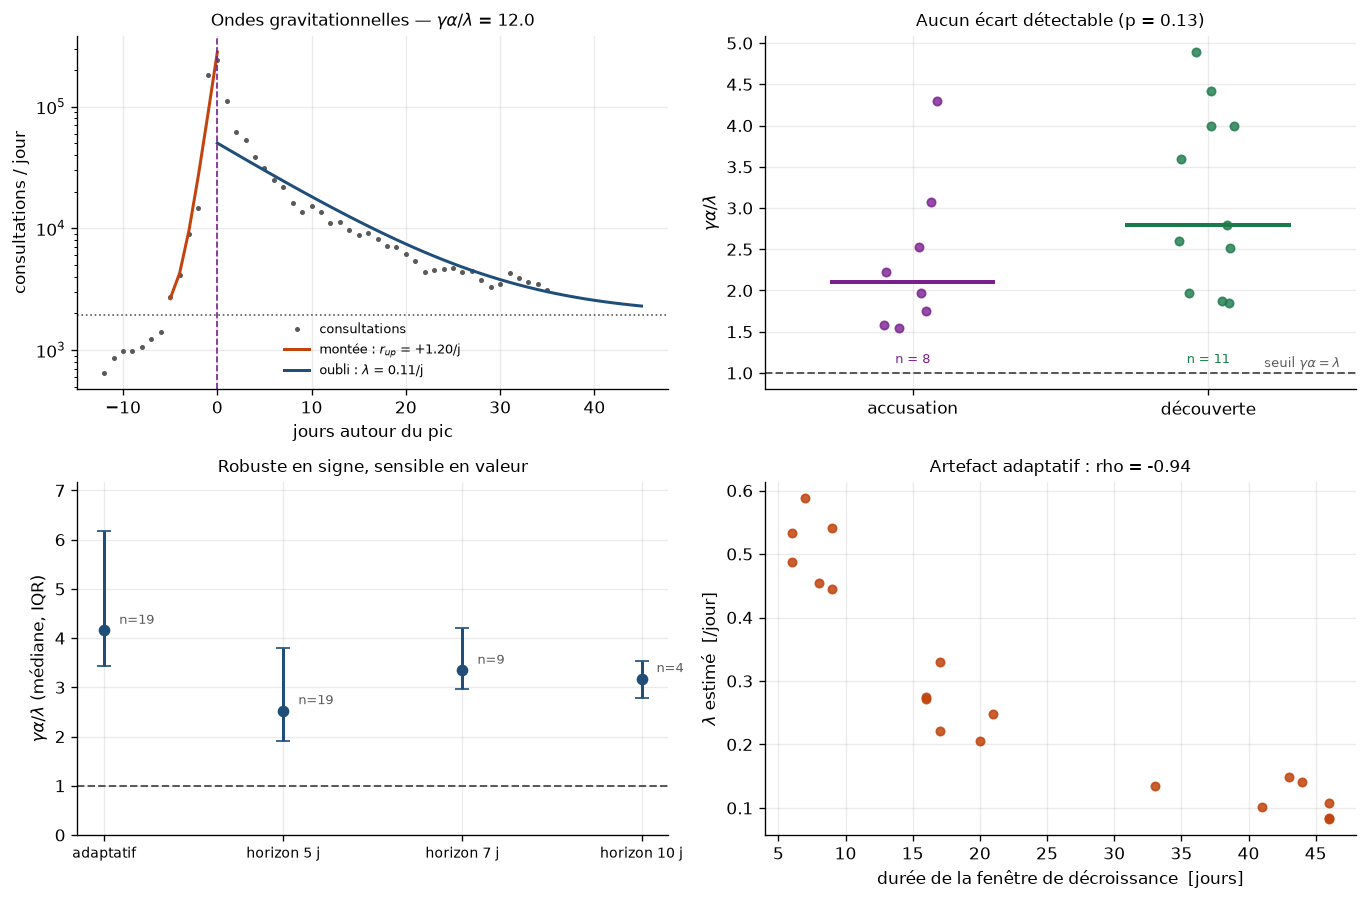

In [6]:
figure, axes = plt.subplots(2, 2, figsize=(11.5, 7.6))
example, distribution, sensitivity, artefact = axes.ravel()

# (a) Un épisode vu de près, en échelle logarithmique.
label, episode = strongest("discovery")
offsets, window, rise_days, rise_line, decay_days, decay_line = episode_frame(label, episode)
example.semilogy(offsets, np.clip(window, 1, None), ".", color=PALETTE["neutral"],
                 markersize=4, label="consultations")
example.semilogy(rise_days, rise_line + episode.baseline, "-", color=PALETTE["disorder"],
                 label=f"montée : $r_{{up}}$ = {episode.rise.rate:+.2f}/j")
example.semilogy(decay_days, decay_line + episode.baseline, "-", color=PALETTE["order"],
                 label=f"oubli : $\\lambda$ = {episode.damping:.2f}/j")
example.axhline(episode.baseline, color=PALETTE["neutral"], linestyle=":", linewidth=1.0)
example.axvline(0, color=PALETTE["field"], linestyle="--", linewidth=1.0)
example.set_xlabel("jours autour du pic")
example.set_ylabel("consultations / jour")
example.set_title(f"{label} — $\\gamma\\alpha/\\lambda$ = {episode.resonance_ratio:.1f}",
                  fontsize=10)
example.legend(fontsize=7.5, loc="lower center")

# (b) Distribution par classe, estimateur à horizon fixe (effectif maximal).
chosen = summary["horizon 5 j"]
rng = np.random.default_rng(0)
for position, (category, colour, name) in enumerate(
    [("accusation", PALETTE["field"], "accusation"), ("discovery", PALETTE["remedy"], "découverte")]
):
    values = chosen["values"][chosen["classes"] == category]
    jitter = position + rng.uniform(-0.10, 0.10, size=values.size)
    distribution.plot(jitter, values, "o", color=colour, markersize=5, alpha=0.8)
    distribution.hlines(np.median(values), position - 0.28, position + 0.28,
                        color=colour, linewidth=2.4)
    distribution.text(position, 1.12, f"n = {values.size}",
                      ha="center", fontsize=8, color=colour)

distribution.axhline(1.0, color=PALETTE["neutral"], linestyle="--", linewidth=1.2)
distribution.text(1.45, 1.06, "seuil $\\gamma\\alpha = \\lambda$", ha="right",
                  fontsize=8, color=PALETTE["neutral"])
distribution.set_xticks([0, 1])
distribution.set_xticklabels(["accusation", "découverte"])
distribution.set_xlim(-0.5, 1.5)
distribution.set_ylabel("$\\gamma\\alpha / \\lambda$")
distribution.set_title(f"Aucun écart détectable (p = {chosen['p']:.2f})", fontsize=10)

# (c) Sensibilité de la médiane au choix d'estimateur.
names = list(ESTIMATORS)
medians = [np.median(summary[name]["values"]) for name in names]
lows = [np.percentile(summary[name]["values"], 25) for name in names]
highs = [np.percentile(summary[name]["values"], 75) for name in names]
counts = [len(summary[name]["values"]) for name in names]

positions = np.arange(len(names))
sensitivity.errorbar(positions, medians,
                     yerr=[np.array(medians) - lows, np.array(highs) - np.array(medians)],
                     fmt="o", color=PALETTE["order"], capsize=4, markersize=6)
for position, median, count in zip(positions, medians, counts):
    sensitivity.annotate(f"n={count}", (position, median), textcoords="offset points",
                         xytext=(9, 4), fontsize=8, color=PALETTE["neutral"])
sensitivity.axhline(1.0, color=PALETTE["neutral"], linestyle="--", linewidth=1.2)
sensitivity.set_xticks(positions)
sensitivity.set_xticklabels(names, fontsize=8.5)
sensitivity.set_ylim(0, max(highs) + 1.0)
sensitivity.set_ylabel("$\\gamma\\alpha / \\lambda$ (médiane, IQR)")
sensitivity.set_title("Robuste en signe, sensible en valeur", fontsize=10)

# (d) L'artefact de l'estimateur adaptatif.
artefact.plot(n_decay, lambdas, "o", color=PALETTE["disorder"], markersize=5, alpha=0.85)
artefact.set_xlabel("durée de la fenêtre de décroissance  [jours]")
artefact.set_ylabel("$\\lambda$ estimé  [/jour]")
artefact.set_title(f"Artefact adaptatif : rho = {rho_lambda.statistic:+.2f}", fontsize=10)

save_figure(figure, "fig09_calibration.png")
plt.show()

## 7. Ce que le notebook établit

**Le chiffre existe.** Sur 19 épisodes d'attention publics, $\gamma\alpha/\lambda$ vaut
entre 1,5 et 12, de médiane 2,5 à 4,2 selon l'estimateur. L'amplification est deux à quatre
fois plus rapide que l'oubli. C'est le premier ancrage empirique du modèle, et il donne
enfin un ordre de grandeur au paramètre le plus important du mémorandum.

**Le critère de signe est vide, et la recommandation doit être réécrite.** Le rapport
dépasse 1 dans *tous* les épisodes, sous *tous* les estimateurs — et c'est logique : par
construction, un épisode d'attention observable a connu une phase de croissance, donc
$r_{\text{up}} > 0$, donc $\gamma\alpha > \lambda$. Vérifier le signe n'apprend rien.

> La recommandation 2 du mémorandum, « interdire les configurations où
> $\gamma\alpha > \lambda$ », est **inapplicable telle qu'elle est formulée**. Ce qu'un
> régulateur peut contraindre, c'est un **plafond sur le rapport** — et la présente mesure
> fournit la référence à partir de laquelle un tel plafond se discute.

**La valeur est sensible à la méthode, le signe ne l'est pas.** La médiane varie d'un
facteur 1,7 entre estimateurs. Toute valeur citée doit l'être avec son estimateur, et un
seuil réglementaire adossé à une valeur unique serait attaquable.

**Le mécanisme de la charge émotionnelle n'est pas étayé.** Aucun écart détectable entre les
deux classes ($p \geq 0,13$), et l'estimation ponctuelle va dans le sens contraire à la
prédiction.

**La méthode est aveugle aux régimes installés.** Les cas archétypaux — QAnon,
désinformation sanitaire, hésitation vaccinale — ne produisent pas de pic mais un
déplacement durable du niveau d'attention, que la détection par proéminence ne voit pas.
C'est la limite la plus lourde, et c'est aussi la piste la plus claire pour la suite :
il faut une méthode de détection de **changement de régime**, pas de pic.

## Pistes ouvertes par ce notebook

1. **Détection de changement de régime** plutôt que de pic, pour atteindre les dynamiques
   d'installation durable — le cas qui compte le plus et qui échappe entièrement à cette
   analyse.
2. **Résolution infra-quotidienne.** Le motif de rejet dominant est la fenêtre trop courte :
   beaucoup d'épisodes montent en un ou deux jours. Des données horaires rendraient
   identifiable ce qui ne l'est pas ici.
3. **Décroissance non exponentielle.** La queue de l'attention est plus lourde qu'une
   exponentielle ; ajuster une loi de puissance ou une somme de deux exponentielles
   supprimerait l'artefact de fenêtre au lieu de le contourner par un horizon fixe.
4. **Une source dotée d'un algorithme de recommandation**, seule voie pour estimer un
   $\gamma$ de plateforme plutôt qu'un gain d'écosystème. C'est l'objet de l'accès aux
   données de l'article 40 du DSA.